In [1]:
#Impot libraries
import pathlib
import os
import datetime

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:128"

import torch
from torch.utils.tensorboard.writer import SummaryWriter
import trimesh
from pytorch3d.loss import chamfer_distance

import utils, dataset, train, visualization
from encoder import *
from decoder import *

%load_ext autoreload
%autoreload 2

/home/nikola/miniconda3/envs/adlr/lib/python3.11/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
# Model name
current_time = datetime.datetime.now().strftime("%b%d_%H-%M")
denoiser_name = "8_Objects_1000timestep_500epochs_12latent_16batch_KL0.001_hidden_dec128"
experiment_name = f"{current_time}_{denoiser_name}"


config = {
    'experiment_name': experiment_name,
    'device': 'cuda:0',
    'batch_size': 16,
    'resume_ckpt': None,
    'learning_rate': 0.0004,
    'step_size': 10, # scheduler step, one step is one batch
    'gamma': 1,
    'max_epochs': 500,
    'timesteps': 1000,
    'print_every_n': 30, # every n batches
    # 'validate_every_n': 10,
    # 'print_EMD_every_n': 1
}

model_config = {
    'last_epoch': 0,
    'enc_hidden_channels': 64,
    'dec_hidden_dim': 128,
    'latent_dim': 12
}

In [3]:
# declare device
if torch.cuda.is_available() and config['device'].startswith('cuda'):
    device = torch.device(config['device'])
    print('Using device:', config['device'])
else:
    device = torch.device('cpu')
    print('Using CPU')

# create dataloaders
trainset = dataset.Dataset('overfit', config['timesteps'])
trainloader = torch.utils.data.DataLoader(trainset, batch_size=config['batch_size'], shuffle=True, num_workers=0, pin_memory=False)
# valset = dataset.Dataset('val', config['timesteps'])
# valloader = torch.utils.data.DataLoader(valset, batch_size=config['batch_size'], shuffle=False, num_workers=0)

encoder = Encoder(number_points=2048, in_channels=3, hidden_channels=model_config['enc_hidden_channels'], latent_dim=model_config['latent_dim'], clamp=False)
decoder = Decoder(number_points=2048, point_dim=3, hidden_dim=model_config['dec_hidden_dim'], latent_dim=model_config['latent_dim'], timesteps=config['timesteps'], beta_start=1e-4, beta_end=0.02)

# move model to specified device
encoder.to(device)
decoder.to(device)
optimizer = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=config['learning_rate'])
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, config['step_size'], config['gamma'])
# scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.0006, steps_per_epoch=len(trainloader), epochs=config['max_epochs'], anneal_strategy='cos', three_phase=True)



# load model if resuming from checkpoint
# experiment_name = "May31_17-04_10_Objects_200epochs_32batch"
# utils.reload_model(encoder, decoder, optimizer, None, experiment_name, 'epoch136', device)


total_enc, trainable_enc = utils.count_parameters(encoder)
total_dec, trainable_dec = utils.count_parameters(decoder)
print(f"Encoder Total: {total_enc:,} | Trainable: {trainable_enc:,} | Model size: {utils.model_memory_size(encoder):.3f} MB")
print(f"Decoder Total: {total_dec:,} | Trainable: {trainable_dec:,} | Model size: {utils.model_memory_size(decoder):.3f} MB")

Using device: cuda:0
Encoder Total: 126,616 | Trainable: 126,616 | Model size: 0.483 MB
Decoder Total: 392,598 | Trainable: 392,598 | Model size: 1.517 MB


In [22]:
torch.cuda.empty_cache()

In [13]:
# start training
torch.cuda.empty_cache()
#tensorboard --logdir=diffusion_autoencoder/logs
# config['max_epochs'] = 200
# Create tensorboard writer    
log_path = pathlib.Path(f"logs/{datetime.datetime.now().strftime('%b%d')}/{config['experiment_name']}")
writer = SummaryWriter(log_path)

with open("debug.txt", "w", encoding="utf-8") as debug_file:
    train.train(encoder, decoder, trainloader, None, device, optimizer, scheduler, config, model_config, writer, None, debug_file)

writer.close()


[00/029] train_loss: 1.108
[00/059] train_loss: 0.983
MSE per timestep integral:  1027.2281698837876
Best Model:   1.0319832355257064
[01/026] train_loss: 0.464
[01/056] train_loss: 0.215
MSE per timestep integral:  293.57228735210373
Best Model:   0.3044200647208426
[02/023] train_loss: 0.171
[02/053] train_loss: 0.167
MSE per timestep integral:  164.77760491943144
Best Model:   0.16085300156994473
[03/020] train_loss: 0.159
[03/050] train_loss: 0.175
MSE per timestep integral:  155.01790473018772
[04/017] train_loss: 0.165
[04/047] train_loss: 0.148
MSE per timestep integral:  153.37623763624578
Best Model:   0.15631998164786232
[05/014] train_loss: 0.167
[05/044] train_loss: 0.144
MSE per timestep integral:  147.82339752480232
Best Model:   0.14368090057183827
[06/011] train_loss: 0.139
[06/041] train_loss: 0.152
MSE per timestep integral:  148.66077510626056
[07/008] train_loss: 0.147
[07/038] train_loss: 0.145
MSE per timestep integral:  148.16331299535233
[08/005] train_loss: 0.1

In [5]:
#Load a model:
experiment_name = "Jun07_08-47_8_Objects_1000timestep_500epochs_12latent_16batch_KL0.001_hidden_dec128"
_,_,encoder, decoder = utils.reload_model(None, None, experiment_name, 'best', device)

In [ ]:
# Old reload
experiment_name = "Jun04_02-43_3_Objects_50epochs_16batch_KL0.001_hidden_dec128_time_emb"
utils.reload_model_old(encoder, decoder, None, None, experiment_name, 'best', device)

In [7]:
generateDDIM = 1
generateDDPM = 0
number_of_points = 2048
DDIM_steps = 50
number_of_DDIM_iterations = 5
save = False
visualize = False

if generateDDIM:
    avg_chamfer = 0.
    for object_index in range(trainset.real_length):
        for i in range(number_of_DDIM_iterations):
            mean, log_variance = encoder(trainset[object_index].unsqueeze(0))
            code = encoder.sample_latent_z(mean, log_variance)

            generated_pc_ddim = sample_ddim(decoder, code, n_points=number_of_points, steps=DDIM_steps, timesteps=config['timesteps'])
            generated_pcd_ddim = trimesh.PointCloud(generated_pc_ddim.squeeze().cpu().numpy())
            
            dist, _ = chamfer_distance(trainset[object_index].unsqueeze(0), generated_pc_ddim)
            avg_chamfer += dist
            print(f"Chamfer distance, Object{object_index}: {dist}")
            if visualize:
                utils.visualize_comparison(trainset[object_index], generated_pc_ddim, window_name="DDIM Target (Red) vs Generated (Blue)")
            
            if save:
                path = pathlib.Path(f"output/{experiment_name}")
                path.mkdir(parents=True, exist_ok=True)
                generated_pcd_ddim.export(path / f"ddim{DDIM_steps}_{number_of_points}_{i}.obj")

    print(f"Average Chamfer distance = {avg_chamfer / (trainset.real_length * number_of_DDIM_iterations)}")

if generateDDPM:
        object_index = 0
        mean, log_variance = encoder(trainset[object_index].unsqueeze(0))
        code = encoder.sample_latent_z(mean, log_variance)
        generated_pc_ddim = sample_ddpm(decoder, code, n_points=number_of_points, timesteps=config['timesteps'])
        generated_pcd_ddim = trimesh.PointCloud(generated_pc_ddim.squeeze().cpu().numpy())
        utils.visualize_comparison(trainset[object_index], generated_pc_ddim, window_name="DDIM Target (Red) vs Generated (Blue)")

Chamfer distance, Object0: 0.0018943429458886385
Chamfer distance, Object0: 0.0015571650583297014
Chamfer distance, Object0: 0.0015318015357479453
Chamfer distance, Object0: 0.0014351955614984035
Chamfer distance, Object0: 0.0016936586471274495
Chamfer distance, Object1: 0.00525572057813406
Chamfer distance, Object1: 0.004953241441398859
Chamfer distance, Object1: 0.004815408959984779
Chamfer distance, Object1: 0.0041364808566868305
Chamfer distance, Object1: 0.004026943817734718
Chamfer distance, Object2: 0.004347066394984722
Chamfer distance, Object2: 0.004221779294312
Chamfer distance, Object2: 0.004280487075448036
Chamfer distance, Object2: 0.004187277518212795
Chamfer distance, Object2: 0.004103769548237324
Chamfer distance, Object3: 0.007154176011681557
Chamfer distance, Object3: 0.0060542128048837185
Chamfer distance, Object3: 0.006570632569491863
Chamfer distance, Object3: 0.006106525659561157
Chamfer distance, Object3: 0.006667696870863438
Chamfer distance, Object4: 0.00324275

Object 0: -0.230 ; [-1.26, 0.74, -0.15, -0.92, -0.01, -0.37, -0.19, -0.19, -0.45, -0.19, 0.19, 0.04]
Object 1: 0.073 ; [1.62, 1.09, -0.41, -0.64, -0.36, 0.09, -0.19, -0.2, -0.27, -0.3, 0.28, 0.16]
Object 2: -0.153 ; [0.62, -0.79, -0.21, 0.58, -0.2, -0.73, -0.67, -0.86, -0.44, 0.46, 0.22, 0.19]
Object 3: 0.025 ; [0.59, 1.78, -0.04, -1.13, 0.07, -1.67, 0.4, 0.14, -0.03, -0.17, 0.32, 0.04]
Object 4: -0.078 ; [0.16, 0.67, -0.05, 0.95, 0.08, -1.16, -0.42, -0.25, -0.68, -0.68, 0.38, 0.05]
Object 5: -0.028 ; [-0.54, 1.57, -0.1, -1.15, -0.11, 0.31, 0.01, -0.2, -0.55, -0.08, 0.34, 0.13]
Object 6: 0.073 ; [1.42, -0.07, -0.19, 0.75, -0.6, 0.99, -0.63, -0.54, -0.55, -0.46, 0.44, 0.32]
Object 7: -0.255 ; [-0.18, -0.71, -0.22, -1.84, -0.02, -0.12, -0.44, -0.28, -0.26, 0.63, 0.25, 0.13]

Running t-SNE with perplexity=7 for 8 samples.


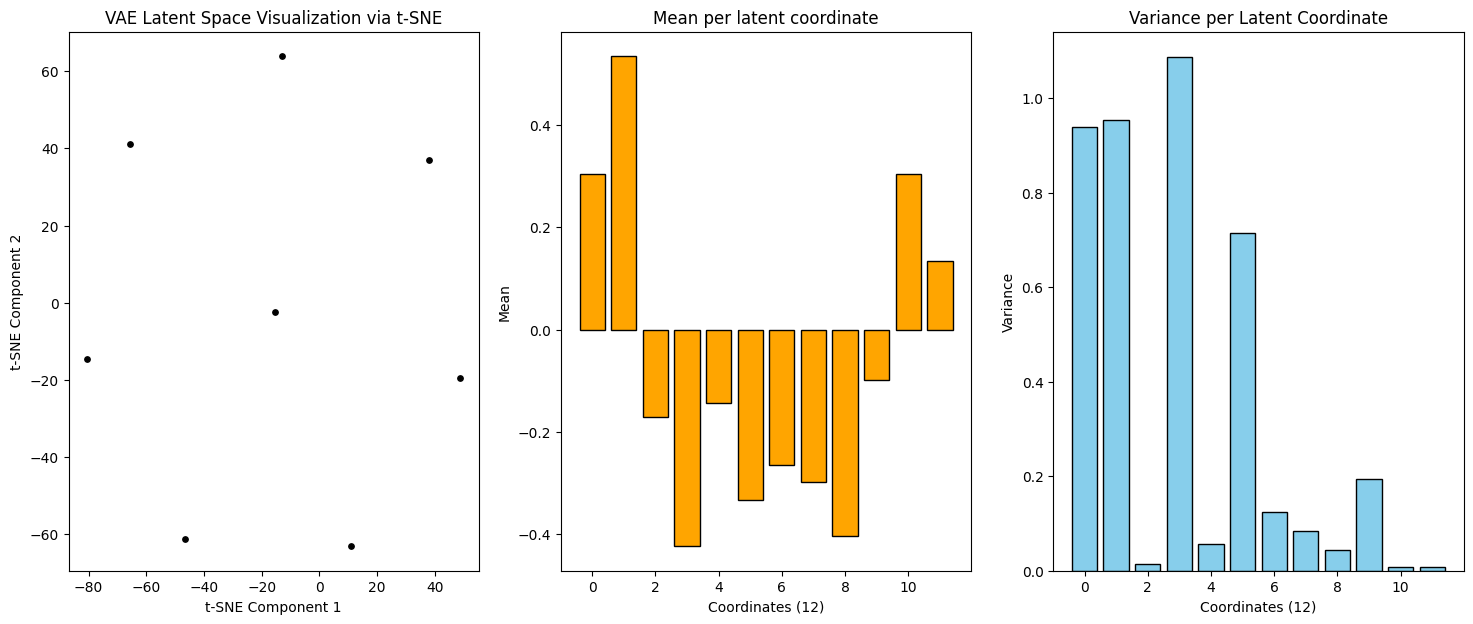

In [8]:
# VAE latent space visualization
import torch
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# 1. Extract latent representations
encoder.eval()
all_latents = []
all_labels = []
mean_matrix = torch.zeros([trainset.real_length, model_config['latent_dim']])

with torch.no_grad():
    for index in range(trainset.real_length):
        data = trainset[index]
        data = data.to(device)
        mu, _ = encoder(data.unsqueeze(0)) 
        mu_list = mu.squeeze().tolist()

        mean_matrix[index] = mu.squeeze(0)
        formatted_dims = [f"{val:.2f}" for val in mu_list]  # Fixed typo from .2 to .2f
        mu_list = [float(x) for x in formatted_dims]
        print(f"Object {index}: {mu.mean():.3f} ; {mu_list}")
        all_latents.append(mu.cpu().numpy())
        all_labels.append(index)

latents = np.concatenate(all_latents, axis=0)
labels = np.array(all_labels)

# 2. Run t-SNE
perplexity = min(30, trainset.real_length - 1)
print(f"\nRunning t-SNE with perplexity={perplexity} for {trainset.real_length} samples.")
tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42, n_jobs=-1)
latents_2d = tsne.fit_transform(latents)

# Mean calculation
# Variance of the latent space + plotting
mean_per_latent_coord = mean_matrix.mean(dim=0).tolist()
# formatted_list = [f"{x:.2f}" for x in mean_matrix.mean(dim=0).tolist()]
# print("Mean per latent coordinate: ")
# print(formatted_list)

# indices = range(len(mean_per_latent_coord))  # Creates [0, 1, 2, 3, 4, 5]


# 3. Calculate Variance per coordinate 
# Changed .mean(dim=0) to .var(dim=0) to match your variable name and objective!
variance_per_latent_coord = mean_matrix.var(dim=0).tolist()
formatted_list = [f"{x:.2f}" for x in variance_per_latent_coord]
# print("\nVariance per latent coordinate: ")
# print(formatted_list)

indices = range(len(variance_per_latent_coord))

# ==========================================
# 4. SIDE-BY-SIDE PLOTTING
# ==========================================
# Create a figure with 1 row and 2 columns
fig, (ax2, ax3, ax1) = plt.subplots(1, 3, figsize=(18, 7))

# Right Plot: t-SNE Scatter Plot
scatter = ax2.scatter(latents_2d[:, 0], latents_2d[:, 1], color = 'black', s=15)
# fig.colorbar(scatter, ax=ax2, label='Item Index') # Colorbar attached specifically to ax2
ax2.set_title("VAE Latent Space Visualization via t-SNE")
ax2.set_xlabel("t-SNE Component 1")
ax2.set_ylabel("t-SNE Component 2")

ax3.bar(indices, mean_per_latent_coord, color='orange', edgecolor='black')
ax3.set_title('Mean per latent coordinate')
ax3.set_xlabel(f'Coordinates ({model_config["latent_dim"]})')
ax3.set_ylabel('Mean')


# Left Plot: Variance Bar Chart
ax1.bar(indices, variance_per_latent_coord, color='skyblue', edgecolor='black')
ax1.set_xlabel(f'Coordinates ({model_config["latent_dim"]})')
ax1.set_ylabel('Variance')
ax1.set_title('Variance per Latent Coordinate')


# Adjust spacing cleanly and showplt.tight_layout()
plt.show()